In [7]:
import warnings, os, sys, joblib, json, pathlib
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb   # pip install xgboost
sns.set(style="ticks", font_scale=1.1)

In [8]:
# Cell 2 ──────────────────────────────────────────────────────────────────
data = datasets.load_breast_cancer(as_frame=True)
df   = data.frame.copy()
df.rename(columns={'target': 'Label'}, inplace=True)   # 1 = Benign, 0 = Malignant
display(df.head())
print(df.shape, "rows × columns")
print("\nClass balance:")
display(df['Label'].value_counts())


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


(569, 31) rows × columns

Class balance:


1    357
0    212
Name: Label, dtype: int64

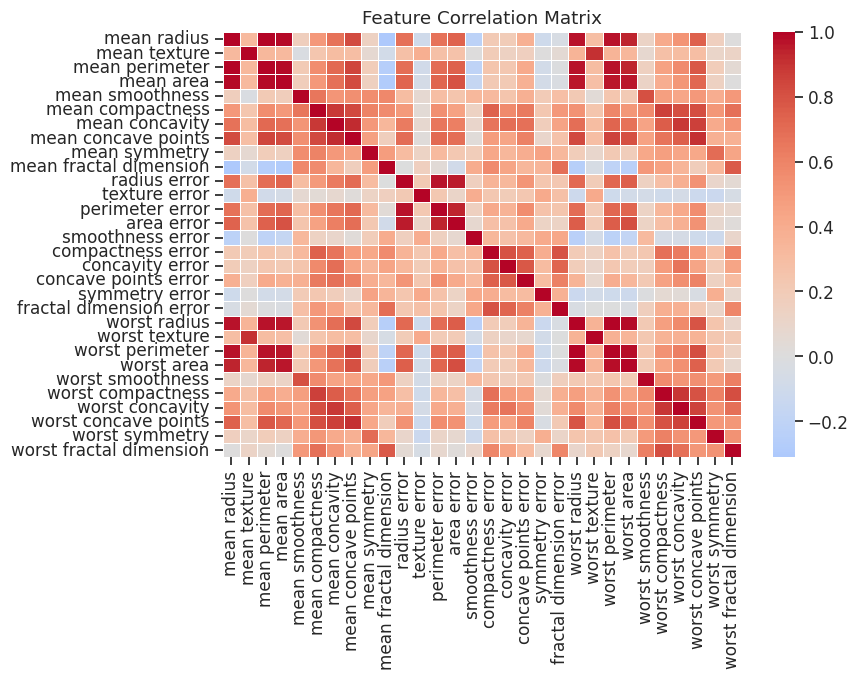

In [25]:
# Cell 2-A  ──────────────────────────────────────────────────────────────
plt.figure(figsize=(9,7))
corr = df.drop(columns='Label').corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [9]:
# Cell 3 ──────────────────────────────────────────────────────────────────
X = df.drop(columns='Label')
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    random_state = 82,
    stratify = y
)


In [10]:
# Cell 4 ──────────────────────────────────────────────────────────────────
# All features are continuous, so a simple StandardScaler suffices
numeric_features = X.columns.tolist()

preproc = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('scaler', StandardScaler())]), numeric_features)
    ]
)


In [18]:
# Cell 5 ──────────────────────────────────────────────────────────────────
models = {
    "LogReg" : (
        LogisticRegression(max_iter=200, solver='liblinear'),
        {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__penalty': ['l1', 'l2']
        }
    ),
    "RandomForest" : (
        RandomForestClassifier(random_state=42),
        {
            'clf__n_estimators': [200, 400],
            'clf__max_depth'   : [None, 8, 16],
            'clf__min_samples_split': [2, 4]
        }
    ),
    "GradientBoost" : (
        GradientBoostingClassifier(random_state=42),
        {
            'clf__n_estimators': [200, 400],
            'clf__learning_rate': [0.05, 0.1],
            'clf__max_depth': [2, 3]
        }
    ),
    "XGBoost" : (
        xgb.XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=42,
            n_jobs=-1
        ),
        {
            'clf__n_estimators': [400, 800],
            'clf__max_depth': [3, 5],
            'clf__learning_rate': [0.03, 0.1],
            'clf__subsample': [0.8, 1.0]
        }
    ),
}


In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# 1️⃣ build the pipeline (uses `preproc` from Cell 4)
logreg_pipe = Pipeline(
    steps=[
        ('prep', preproc),
        ('clf',  LogisticRegression(max_iter=200, solver='liblinear'))
    ]
)

# 2️⃣ quick cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
auc_scores = cross_val_score(
    logreg_pipe,
    X_train, y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
mean_auc = auc_scores.mean()
print(f"3-fold ROC-AUC: {mean_auc:.4f}")

# 3️⃣ fit on the full training split for later evaluation (Cell 7)
logreg_pipe.fit(X_train, y_train)

# 4️⃣ keep things in the expected variables for downstream cells
models = {"LogReg": logreg_pipe}
cv_df = pd.DataFrame(
    {"Model": ["LogReg"], "AUC_CV": [mean_auc], "Notes": ["default params"]}
)

display(cv_df)

3-fold ROC-AUC: 0.9952


,Model,AUC_CV,Notes
0,LogReg,0.995196,default params


Accuracy  : 0.9386

Classification report ▸
              precision    recall  f1-score   support

   Malignant       0.95      0.88      0.91        42
      Benign       0.93      0.97      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



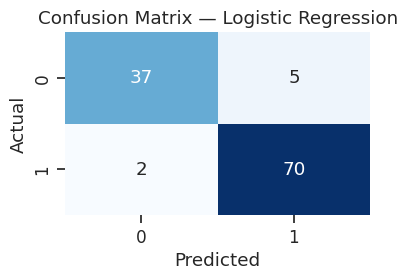

In [22]:
# Cell 7 ────────────────────────────────────────────────────────────────
"""
Hold-out evaluation + confusion matrix
"""
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on the held-out test split (created in Cell 3)
y_pred  = models["LogReg"].predict(X_test)
y_proba = models["LogReg"].predict_proba(X_test)[:, 1]

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification report ▸")
print(classification_report(y_test, y_pred,
                            target_names=["Malignant", "Benign"]))

# Confusion-matrix heat-map
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


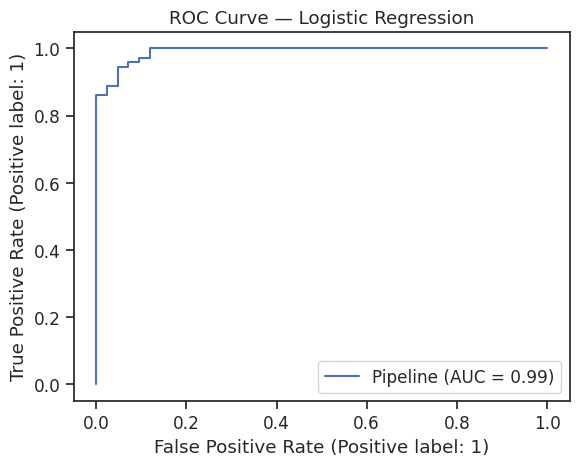

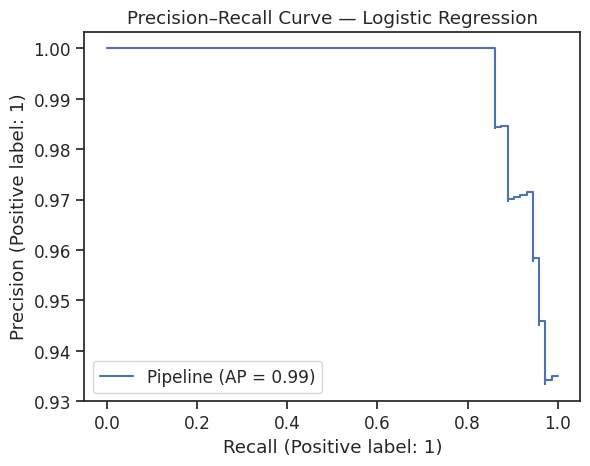

In [23]:
# Cell 8 ────────────────────────────────────────────────────────────────
"""
ROC and Precision-Recall curves
"""
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# ROC curve
RocCurveDisplay.from_estimator(models["LogReg"], X_test, y_test)
plt.title("ROC Curve — Logistic Regression")
plt.show()

# Precision-Recall curve
PrecisionRecallDisplay.from_estimator(models["LogReg"], X_test, y_test)
plt.title("Precision–Recall Curve — Logistic Regression")
plt.show()


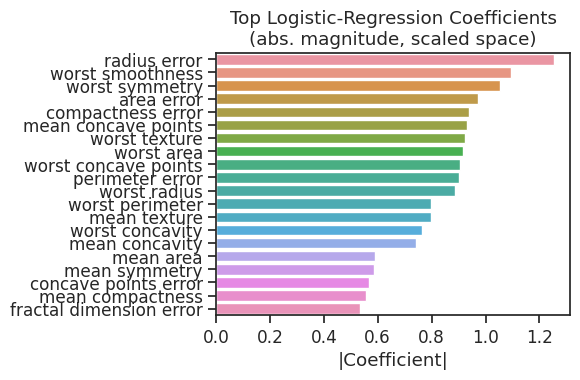

In [24]:
# Cell 9 ────────────────────────────────────────────────────────────────
"""
Feature-weight bar plot (absolute coefficients from the scaled model)
"""
import numpy as np

clf        = models["LogReg"].named_steps["clf"]
feat_names = X.columns  # original column order
coefs      = clf.coef_[0]

# Take absolute value, sort descending
idx_sorted = np.argsort(np.abs(coefs))[::-1][:20]   # top-20 for readability
plt.figure(figsize=(6, 4))
sns.barplot(x=np.abs(coefs[idx_sorted]),
            y=np.array(feat_names)[idx_sorted],
            orient="h")
plt.title("Top Logistic-Regression Coefficients\n(abs. magnitude, scaled space)")
plt.xlabel("|Coefficient|"); plt.ylabel("")
plt.tight_layout(); plt.show()
